# Matching and comparison of the database with external sources

In [205]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [206]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "validation_external_sources"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [279]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
# res_name_llm = "post_processed_0-350_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v200426_v210426_geo"
res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"
 
cols = [
    "appealCode", 
    "reportDate",
    "impactSubtype", 
    "impactValue", 
    "impactValueMin", 
    "impactValueMax", 
    "impactValuePrecision", 
    "impactUnit",
    "valueAnnotation", 
    "location", 
    "locationAnnotation", 
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards", 
    'startYear', 
    'startMonth', 
    'startDay', 
    'endYear', 
    'endMonth', 
    'endDay'
]
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)
df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
# df_llm_all = format_output(df_llm_all, list_cols=LIST_COLS+["country_robust_iso3"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v191225.gpkg'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_38512\2785369508.py:33: DtypeWarning: Columns (27,28,29,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')


In [280]:
col_to_list = ["location", "hazards", "country_robust_iso3"]
df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

In [281]:
df_llm_all_geo_grp = clean_group(df_llm_all, ADM_min=0)

In [282]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
# df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)
df_em_dat = open_emdat()

df_external_source = {}
df_external_source["IFRCGO"] = df_ifrc_go
# df_external_source["ifrc_monty"] = df_ifrc_monty
df_external_source["EMDAT"] = df_em_dat

In [283]:
df_llm_all_geo_grp_linked = {}

# # MATCHING WITH IFRC MONTY 
# df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
# df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

# IFRCGO
df_ifrc_go_clean = clean_structure_ifrc_go(df_ifrc_go)
df_llm_all_geo_grp_linked["IFRCGO"] = df_llm_all_geo_grp.merge(
    df_ifrc_go_clean,
    left_on=["appealCode", "impactSubtype"],
    right_on=["IFRCGO_appealCode", "IFRCGO_impactSubtype"],
    how="left",
)

# Build long-format EMDAT impacts
df_em_dat_clean = clean_structure_emdat(df_em_dat)
df_em_dat_clean.head()

# MATCHING WITH EMDAT
months = 3
date_diff_th = datetime.timedelta(days=months*30)
df_llm_all_geo_linked, df_llm_em_dat = matching_emdat(
    df_llm_all_geo_grp,
    df_em_dat_clean,
    date_diff_th,
    "date_diff_start",
    country_field='country_robust_iso3',
)
df_llm_all_geo_grp_linked["EMDAT"] = df_llm_all_geo_linked

# Combined linked dataframe with both EMDAT and IFRCGO matched columns
ifrc_cols = [c for c in df_llm_all_geo_grp_linked["IFRCGO"].columns if c.startswith("IFRCGO_")]
df_llm_all_linked = df_llm_all_geo_grp_linked["EMDAT"].merge(
    df_llm_all_geo_grp_linked["IFRCGO"][["appealCode", "impactSubtype"] + ifrc_cols].drop_duplicates(),
    on=["appealCode", "impactSubtype"],
    how="left",
)
df_llm_all_geo_grp_linked["ALL"] = df_llm_all_linked

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "Missing People" : {"ifrc_monty" : "missing", "ifrc_go" : "num_missing", "emdat" : None},


In [94]:
print("Number of unique appealCode from the IFRCGO API : ", df_external_source["ifrc_go"]["appealCode"].nunique())
print("Number of unique common appealCode with the LLM-extracted reports : ", df_llm_all_geo_grp.loc[df_llm_all_geo_grp["appealCode"].isin(df_external_source["ifrc_go"]["appealCode"].unique())]["appealCode"].nunique())

Number of unique appealCode from the IFRCGO API :  2728
Number of unique common appealCode with the LLM-extracted reports :  291


In [96]:
print("Number of unique appealCode from the IFRC Monty API : ", df_external_source["ifrc_monty"]["appealCode"].nunique())
print("Number of unique common appealCode with the LLM-extracted reports : ", df_llm_all_geo_grp.loc[df_llm_all_geo_grp["appealCode"].isin(df_external_source["ifrc_monty"]["appealCode"].unique())]["appealCode"].nunique())

Number of unique appealCode from the IFRC Monty API :  351
Number of unique common appealCode with the LLM-extracted reports :  147


In [ ]:
print("Number of unique appealCode from the emdat : ", df_external_source["emdat"]["DisNo."].nunique())

Number of unique appealCode from the IFRCGO API :  14935


# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

In [284]:
impact_subtypes = list(mapping_impact_type.keys())

### Plot of % of reports with impact information 

In [285]:
# Build counts/% for ROUGE + linked IFRCGO + linked EMDAT
impact_subtypes_input = list(mapping_impact_type.keys())

linked_sources_cfg = {
    "IFRCGO": {
        "df": df_llm_all_geo_grp_linked["IFRCGO"],
        "value_col": "IFRCGO_impactValue",
        "source_subtype_col": "IFRCGO_impactSubtype",
    },
    "EMDAT": {
        "df": df_llm_all_geo_grp_linked["EMDAT"],
        "value_col": "EMDAT_impactValue",
        "source_subtype_col": "EMDAT_ImpactSubtype",
    },
}

impact_count_summary, nb_report_with_impact, perc_report_with_impact = count_impacts_by_subtype(
    df_rouge=df_llm_all_geo_grp,
    linked_sources=linked_sources_cfg,
    impact_subtypes=impact_subtypes_input,
)

In [291]:
impact_count_summary

,impactSubtype,ROUGE_count,ROUGE_perc,IFRCGO_count,IFRCGO_perc,EMDAT_count,EMDAT_perc
0,Affected People,680,97.142857,307,43.857143,474,67.714286
1,Injured People,204,29.142857,100,14.285714,115,16.428571
2,Displaced People,397,56.714286,167,23.857143,0,0.000000
3,Human Deaths,400,57.142857,193,27.571429,282,40.285714
4,Missing People,113,16.142857,51,7.285714,0,0.000000
5,Homeless People,209,29.857143,0,0.000000,24,3.428571


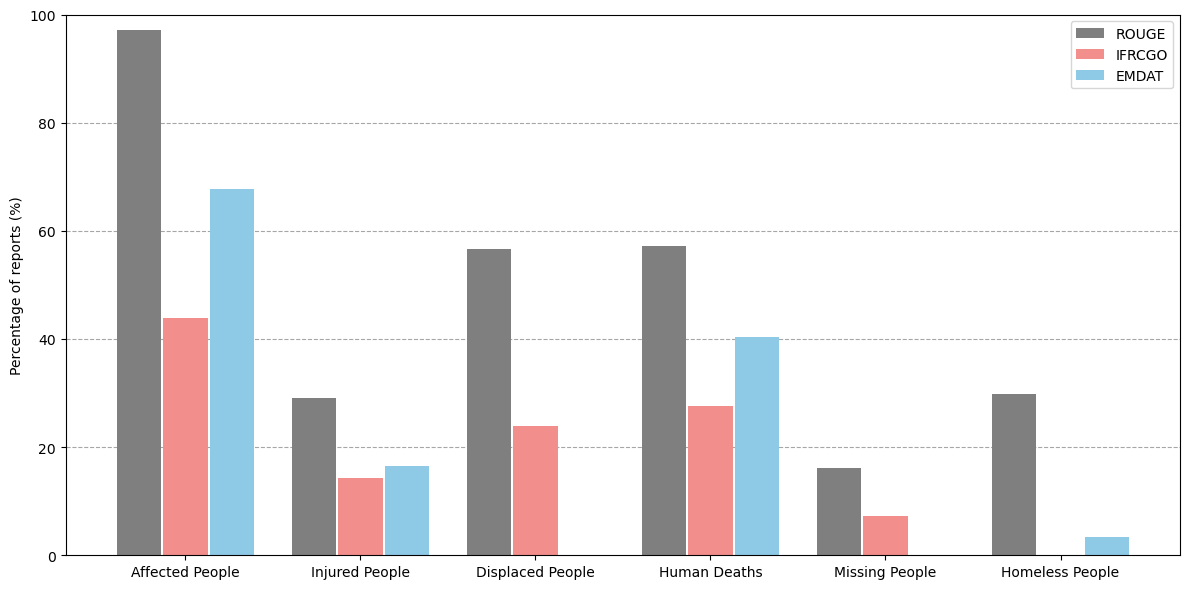

In [286]:
impact_types = list(mapping_impact_type.keys())
x = np.arange(len(impact_types))

# Plot sources in a fixed order when available in the new dictionary format
plot_sources = [s for s in ["ROUGE", "IFRCGO", "EMDAT"] if s in perc_report_with_impact]
width = 0.8 / max(len(plot_sources), 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Colors aligned with the new source names
colors = {
    "ROUGE": "#7f7f7f",
    "IFRCGO": "#f28e8b",
    "EMDAT": "#8ecae6",
}

for i, source in enumerate(plot_sources):
    offset = (i - (len(plot_sources) - 1) / 2) * width
    ax.bar(
        x + offset,
        perc_report_with_impact[source],
        width * 0.95,
        label=source,
        color=colors.get(source, "grey"),
    )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(impact_types)
ax.set_ylabel("Percentage of reports (%)")
ax.legend()

for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

ax.set_ylim(0, 100)

plt.tight_layout()
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.png", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar Plot after event matching

In [290]:
nb_matched = {}

In [297]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}
df_matched_with_impact = {}

tolerance = 0.10

def compute_matching_metrics_from_linked_df(
    df_linked,
    value_col,
    impact_subtypes,
    tolerance=0.10,
    compare_col="IFRCGO",
    compare_prefix=None,
 ):
    """
    Compute matching metrics per impact subtype from a linked dataframe.

    Expected columns in df_linked:
    - appealCode
    - impactSubtype
    - impactValue_final
    - external value column (value_col)
    - optional comparison column (compare_col), e.g. EMDAT vs IFRCGO in linked ALL
    """
    out_nb_matched = []
    out_nb_exact_match = []
    out_nb_no_external_impact = []
    out_df_matched_with_impact = pd.DataFrame()

    for impactSubtype in impact_subtypes:
        df_sub = df_linked.loc[df_linked["impactSubtype"] == impactSubtype].copy()

        n_before = len(df_sub)
        if value_col not in df_sub.columns:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # Only compute ROUGE-vs-external rel_diff when both values exist
        df_sub = df_sub.dropna(subset=["impactValue_final", value_col])
        n_after = len(df_sub)

        if n_after == 0:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # ROUGE vs external source metrics
        df_sub["abs_diff"] = (df_sub["impactValue_final"] - df_sub[value_col]).abs()
        df_sub["rel_diff"] = (
            (df_sub["impactValue_final"] - df_sub[value_col])
            / df_sub[value_col].replace(0, np.nan)
        )
        df_sub["abs_rel_diff"] = df_sub["rel_diff"].abs()
        df_sub["match"] = df_sub["abs_rel_diff"] <= tolerance

        # Optional external-vs-external comparison (e.g., EMDAT relative to IFRCGO)
        if compare_col is not None and compare_col in df_sub.columns:
            pair_prefix = compare_prefix or f"{value_col}_vs_{compare_col}"
            valid_pair = df_sub[[value_col, compare_col]].notna().all(axis=1)
            df_sub[f"{pair_prefix}_abs_diff"] = np.where(
                valid_pair,
                (df_sub[value_col] - df_sub[compare_col]).abs(),
                np.nan,
            )
            df_sub[f"{pair_prefix}_rel_diff"] = np.where(
                valid_pair,
                (df_sub[value_col] - df_sub[compare_col]) / df_sub[compare_col].replace(0, np.nan),
                np.nan,
            )
            df_sub[f"{pair_prefix}_abs_rel_diff"] = df_sub[f"{pair_prefix}_rel_diff"].abs()
            df_sub[f"{pair_prefix}_match"] = df_sub[f"{pair_prefix}_abs_rel_diff"] <= tolerance

        out_df_matched_with_impact = pd.concat(
            [out_df_matched_with_impact, df_sub],
            axis=0,
            ignore_index=True,
        )

        out_nb_no_external_impact.append(n_before - n_after)
        out_nb_matched.append(df_sub["appealCode"].nunique())
        out_nb_exact_match.append(df_sub.loc[df_sub["match"], "appealCode"].nunique())

    return {
        "nb_matched": out_nb_matched,
        "nb_exact_match": out_nb_exact_match,
        "nb_no_external_impact": out_nb_no_external_impact,
        "df_matched_with_impact": out_df_matched_with_impact,
    }


# Run for linked IFRCGO and EMDAT using their standardized impact value columns
source_cfg = {
    "IFRCGO": {"linked_key": "IFRCGO", "value_col": "IFRCGO_impactValue"},
    "EMDAT": {"linked_key": "EMDAT", "value_col": "EMDAT_impactValue"},
    "ALL": {
        "linked_key": "ALL",
        "value_col": "EMDAT_impactValue",
        "compare_col": "IFRCGO_impactValue",
        "compare_prefix": "EMDAT_vs_IFRCGO",
    },
}

for source_name, cfg in source_cfg.items():
    metrics = compute_matching_metrics_from_linked_df(
        df_linked=df_llm_all_geo_grp_linked[cfg["linked_key"]],
        value_col=cfg["value_col"],
        impact_subtypes=list(mapping_impact_type.keys()),
        tolerance=tolerance,
        compare_col=cfg.get("compare_col"),
        compare_prefix=cfg.get("compare_prefix"),
    )

    nb_matched[source_name] = metrics["nb_matched"]
    nb_exact_match[source_name] = metrics["nb_exact_match"]
    nb_no_external_impact[source_name] = metrics["nb_no_external_impact"]
    df_matched_with_impact[source_name] = metrics["df_matched_with_impact"]

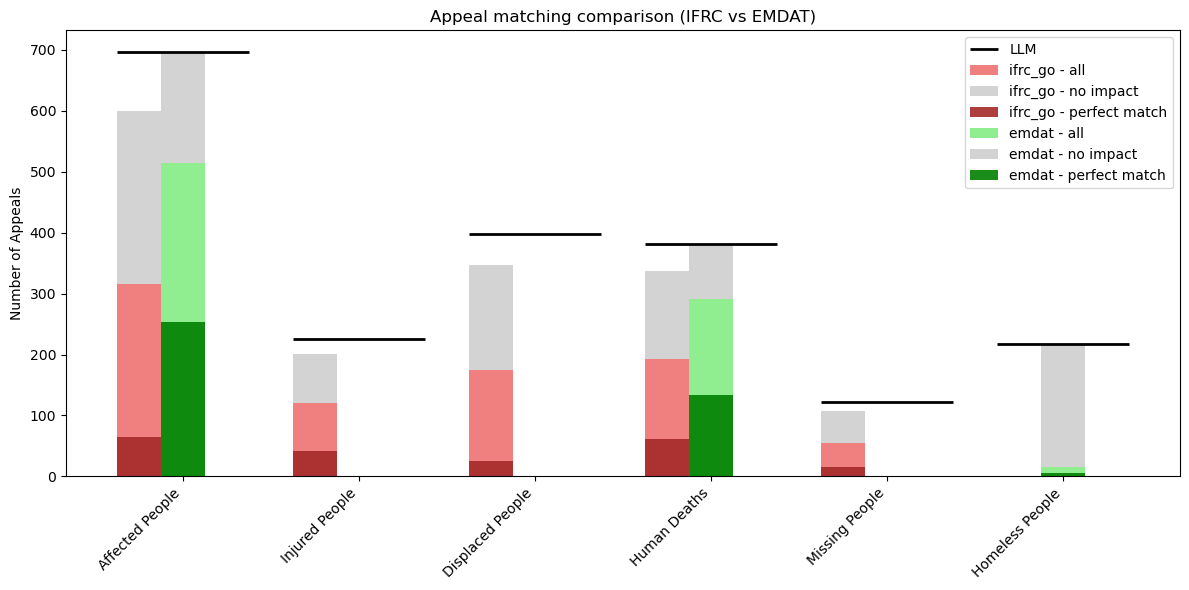

In [162]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors
colors = {
    "ifrc_monty": ["skyblue", "dodgerblue"],
    "emdat": ["lightgreen", "green"],
    "ifrc_go": ["lightcoral", "brown"],
}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    # Base bars ("all")
    bars_all = ax.bar(
        x + (i-1)*width,
        nb_matched[external_source],
        width,
        label=external_source + " - all",
        color=colors[external_source][0],
    )

    # Add stacked bar ("no external impact") on top of "all"
    ax.bar(
        x + (i-1)*width,
        nb_no_external_impact[external_source],
        width,
        bottom=nb_matched[external_source],
        label=external_source + " - no impact",
        color="lightgray",
        # edgecolor="gray",
    )

    # "Perfect match" bars
    ax.bar(
        x + (i-1)*width,
        nb_exact_match[external_source],
        width,
        label=external_source + " - perfect match",
        color=colors[external_source][1],
        alpha=0.9,
    )

# Target lines
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(
        y=y,
        xmin=xi - total_bar_width/2,
        xmax=xi + total_bar_width/2,
        colors='black',
        linewidth=2,
        label="LLM" if xi == 0 else ""
    )

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()
plt.tight_layout()
plt.show()

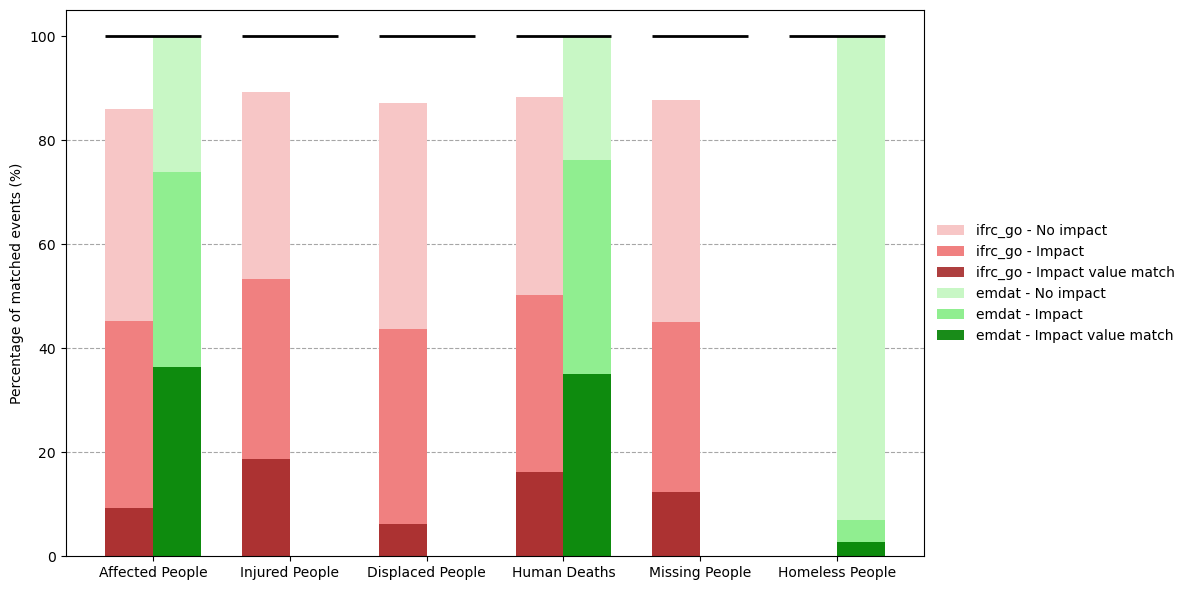

In [163]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # wider bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors
colors = {
    "emdat": {
        "all": "lightgreen",
        "no_impact": "#c8f7c5",  # very light green
        "exact": "green",
    },
    "ifrc_go": {
        "all": "lightcoral",
        "no_impact": "#f7c6c6",  # very light red
        "exact": "brown",
    },
}

# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width  # positions for side-by-side bars

    # Combine total (all + no external impact + exact match) as one stacked bar
    ax.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=external_source + " - No impact",
        color=colors[external_source]["no_impact"],
    )
    
    ax.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=external_source + " - Impact",
        color=colors[external_source]["all"],
    )

    ax.bar(
        x + offset,
        nb_exact_match_pct[external_source],
        width,
        label=external_source + " - Impact value match",
        color=colors[external_source]["exact"],
        alpha=0.9,
    )

# Reference line at 100%
for xi in x:
    ax.hlines(
        y=100,
        xmin=xi - width,
        xmax=xi + width,
        colors='black',
        linewidth=2
    )

# Add dashed horizontal gridlines at 20, 40, 60, 80%
for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Labels and formatting
ax.set_xticks(x)
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_xticklabels(mapping_impact_type.keys())
ax.set_ylabel("Percentage of matched events (%)")
ax.set_ylim(0, 105)
# ax.set_title("Appeal matching comparison (IFRC vs EMDAT) — % of extracted appeals")
ax.legend()

# Move the legend box outside 
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
plt.tight_layout()

#Save fig 
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

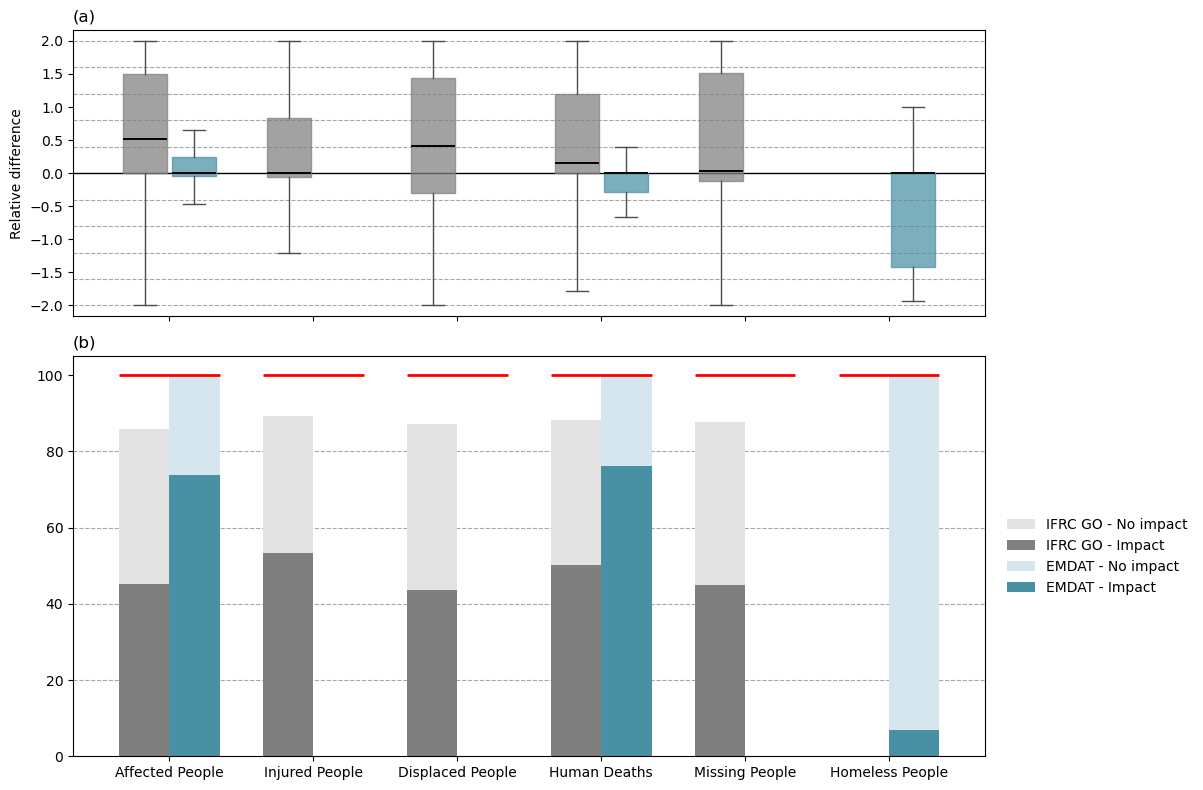

In [164]:
impact_categories = list(mapping_impact_type.keys())
x = np.arange(len(impact_categories))

# Shared colors
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

fig, (ax_err, ax_bar) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [1, 1.4]},
    sharex=True,
    constrained_layout=False,
 )

# =====================
# 1) Error plot (rel_diff)
# =====================
width_box = 0.34
box_data = []
box_positions = []
box_colors = []

for i, impactSubtype in enumerate(impact_categories):
    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        box_positions.append(i - width_box / 2)
        box_colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        box_positions.append(i + width_box / 2)
        box_colors.append(color_emdat)

if box_data:
    bp = ax_err.boxplot(
        box_data,
        positions=box_positions,
        widths=width_box * 0.9,
        patch_artist=True,
        showfliers=False,
    )

    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.72)
        patch.set_edgecolor(c)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in bp["whiskers"]:
        whisker.set_color("#4d4d4d")

    for cap in bp["caps"]:
        cap.set_color("#4d4d4d")

    max_abs = np.nanmax(np.abs(np.concatenate([arr for arr in box_data if len(arr) > 0])))
    if not np.isfinite(max_abs) or max_abs <= 0:
        max_abs = 1
else:
    max_abs = 1

ylim = max_abs * 1.08
ax_err.set_ylim(-ylim, ylim)

# Dashed gridlines for both positive and negative values
grid_levels = np.linspace(0, max_abs, 6)[1:]
for y in grid_levels:
    ax_err.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
    ax_err.axhline(y=-y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
ax_err.axhline(y=0, color="black", linewidth=1, zorder=1)

ax_err.set_ylabel("Relative difference")
ax_err.set_title("(a)", loc="left")

# err_legend_handles = [
#     plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
#     plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
# ]
# ax_err.legend(handles=err_legend_handles, loc="upper right", frameon=False)

# =====================
# 2) matched_events_ext_quanti_impact plot
# =====================
width = 0.35

colors = {
    "emdat": {
        "all": "#4a90a4",        # light desaturated blue
        "no_impact": "#d6e6ef",  # very light blue
        # "all": "#b8d4e3",        # light desaturated blue
        # "no_impact": "#d6e6ef",  # very light blue
        # "exact": "#4a90a4",      # muted blue-grey
    },
    "ifrc_go": {
        "all": "#7f7f7f",        # light grey
        "no_impact": "#e3e3e3",  # very light grey
        # "all": "#c8c8c8",        # light grey
        # "no_impact": "#e3e3e3",  # very light grey
        # "exact": "#7f7f7f",      # medium grey
    },
}

# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
# nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width
    source_label = external_source.replace("_", " ").upper()

    # No external impact (top segment)
    ax_bar.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=source_label + " - No impact",
        color=colors[external_source]["no_impact"],
    )

    # Matched (middle segment)
    ax_bar.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=source_label + " - Impact",
        color=colors[external_source]["all"],
    )

    # # Exact match (overlay)
    # ax_bar.bar(
    #     x + offset,
    #     nb_exact_match_pct[external_source],
    #     width,
    #     label=source_label + " - Impact value match",
    #     color=colors[external_source]["exact"],
    #     alpha=0.9,
    # )

# Reference 100% line
for xi in x:
    ax_bar.hlines(y=100, xmin=xi - width, xmax=xi + width, colors='red', linewidth=2)

# Horizontal dashed lines
for y in [20, 40, 60, 80]:
    ax_bar.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# # Quantitative markers
# marker_color_ifrc = "dimgray"
# marker_color_emdat = "#4a90a4"
# marker_color_llm = "red"

# pos_ifrc_go = x - width/2
# pos_emdat = x + width/2
# pos_llm = x

# ax_bar.scatter(
#     pos_ifrc_go,
#     perc_report_with_impact["ifrc_go"],
#     marker='s',
#     s=90,
#     color=marker_color_ifrc,
#     label="IFRC GO (quantitative)",
#     zorder=12
# )

# ax_bar.scatter(
#     pos_emdat,
#     perc_report_with_impact["emdat"],
#     marker='s',
#     s=90,
#     color=marker_color_emdat,
#     label="EMDAT (quantitative)",
#     zorder=12
# )

# ax_bar.scatter(
#     pos_llm,
#     perc_report_with_impact_llm,
#     marker='s',
#     s=90,
#     color=marker_color_llm,
#     label="LLM (quantitative)",
#     zorder=12
# )

# ax2.set_ylim(0, 100)

# Formatting
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(impact_categories)
ax_bar.set_ylabel("")
ax_bar.set_ylim(0, 105)
ax_bar.set_title("(b)", loc="left")

# Combined legend for bottom panel
handles1, labels1 = ax_bar.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()
ax_bar.legend(
    handles1,
    labels1,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
 )

plt.tight_layout()

# Save combined figure if needed
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.pdf",
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

## Bar plot comparison

## Bar plot relative error 

In [295]:
df_matched_with_impact.keys()

dict_keys(['IFRCGO', 'EMDAT', 'ALL'])

In [298]:
nb_matched.keys()

dict_keys(['IFRCGO', 'EMDAT', 'ALL'])

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_38512\3601072438.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


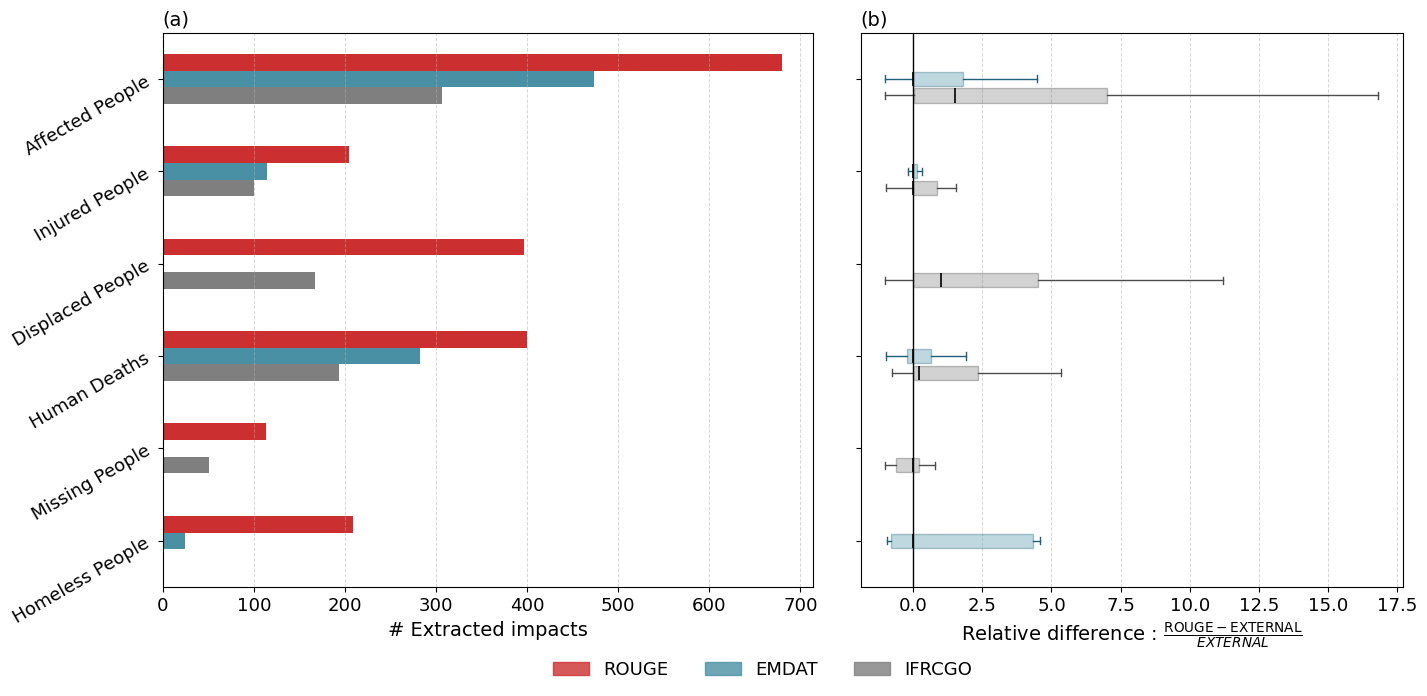

In [299]:
# (a)-(b) Two-column aligned plot: report counts and rel_diff distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

# Font sizes
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# Pick IFRC key available in both dictionaries (prefer IFRCGO)
if "IFRCGO" in nb_matched and "IFRCGO" in df_matched_with_impact:
    ifrc_key = "IFRCGO"
else:
    ifrc_key = "IFRC MONTY"

# External sources to compare
ext_sources = ["EMDAT", ifrc_key]
if INCLUDE_IFRC_MONTY and "IFRC MONTY" in nb_matched and "IFRC MONTY" in df_matched_with_impact and "IFRC MONTY" not in ext_sources:
    ext_sources.append("IFRC MONTY")

# Build left-panel series (ROUGE + external sources)
left_series = ["ROUGE"] + ext_sources

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary
counts_map = {
    "ROUGE": np.array(impact_count_summary['ROUGE_count'].values, dtype=float),
    "EMDAT": np.array(impact_count_summary['EMDAT_count'].values, dtype=float),
    "IFRCGO": np.array(impact_count_summary['IFRCGO_count'].values, dtype=float),
    "IFRC MONTY": np.array(
        impact_count_summary['IFRC MONTY_count'].values 
        if 'IFRC MONTY_count' in impact_count_summary.columns 
        else [0] * n_types, 
        dtype=float
    ),
}

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.2, 1.0], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
# ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("# Extracted impacts", fontsize=tick_fs+1)
ax_a.set_title("(a)", fontsize=tick_fs+1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)

# =====================
# (b) Horizontal boxplot of rel_diff
# =====================
box_h = bar_h * 0.85
box_style = {
    "EMDAT": {"face": "#4a90a4", "edge": "#1f5f78"},
    "IFRCGO": {"face": "#7f7f7f", "edge": "#4d4d4d"},
    "IFRC MONTY": {"face": "#b08968", "edge": "#7f5539"},
}

for s in ext_sources:
    box_vals = []
    box_pos = []

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_matched_with_impact.get(s, pd.DataFrame())
            .loc[lambda d: d["impactSubtype"] == impact_type, "rel_diff"]
            .dropna()
            .values
        )

        if len(vals) > 0:
            box_vals.append(vals)
            box_pos.append(y[i] + offset_map[s])

    if box_vals:
        bp = ax_b.boxplot(
            box_vals,
            positions=box_pos,
            vert=False,
            widths=box_h,
            patch_artist=True,
            showfliers=False,
        )

        for box in bp["boxes"]:
            box.set_facecolor(box_style[s]["face"])
            box.set_alpha(0.35)
            box.set_edgecolor(box_style[s]["edge"])
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        for whisker in bp["whiskers"]:
            whisker.set_color(box_style[s]["edge"])
        for cap in bp["caps"]:
            cap.set_color(box_style[s]["edge"])

ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel(
    "Relative difference : " + r"$\frac{\mathrm{ROUGE-EXTERNAL}}{EXTERNAL}$",
    fontsize=tick_fs + 1
)
ax_b.set_title("(b)", fontsize=tick_fs+1, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

# Single shared legend for both subplots
shared_handles = [Patch(facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=bar_labels[s]) for s in left_series]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    fontsize=legend_fs,
    title_fontsize=legend_fs,
 )
plt.tight_layout(rect=[0, 0.06, 1, 1])

#Save figure

# fig.savefig(path_save_fig / f"comparaison_external_events_values.png", plt.show()

#             transparent=True, bbox_inches='tight', dpi=300)#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"comparaison_external_events_values.svg", 

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_38512\2911563892.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


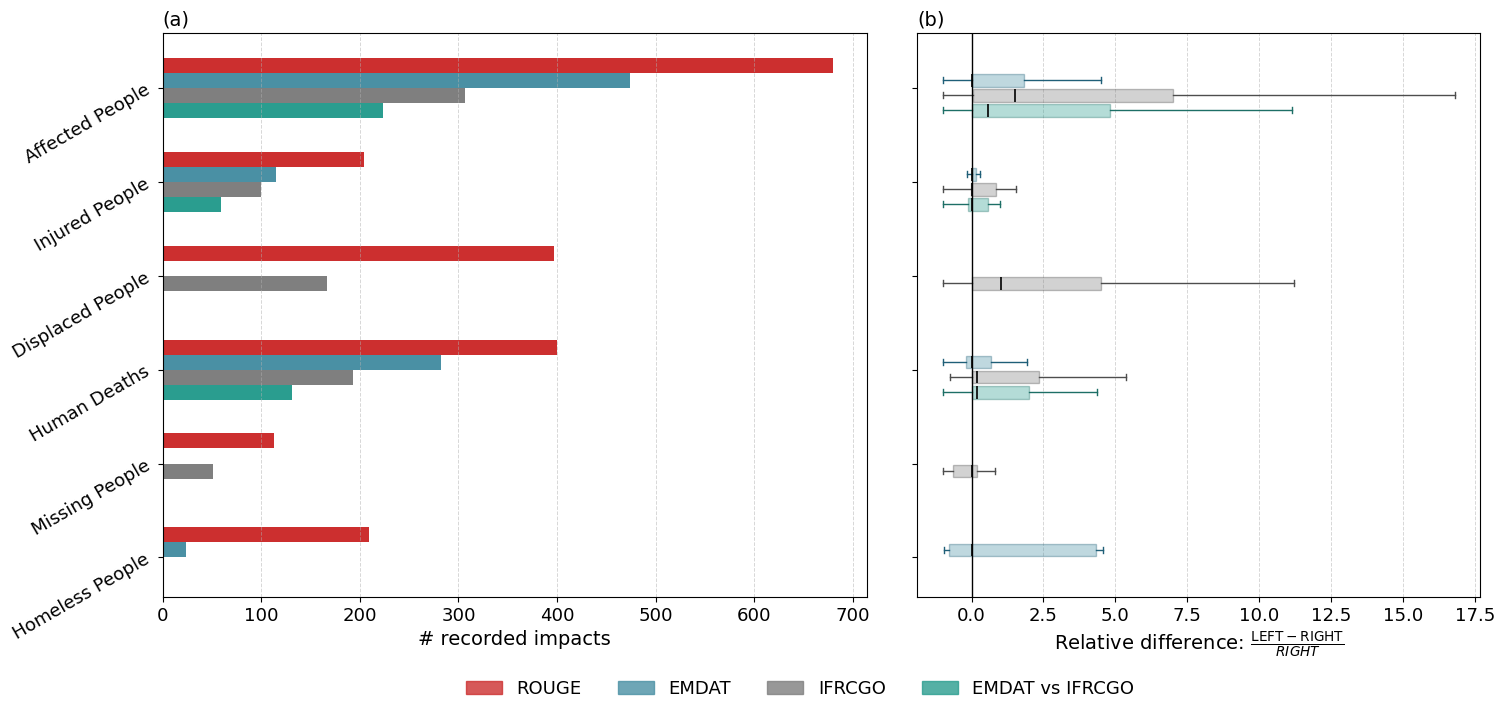

In [301]:
# (a)-(b) Alternative comparison including EMDAT vs IFRCGO pairwise metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

INCLUDE_IFRC_MONTY = False
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
n_types = len(impact_types)
y = np.arange(n_types)
impact_labels = impact_types

# Pairwise count: number of recorded impacts with both EMDAT and IFRCGO values
pair_col = "EMDAT_vs_IFRCGO_rel_diff"
df_all_pair = df_matched_with_impact.get("ALL", pd.DataFrame()).copy()
if pair_col in df_all_pair.columns:
    pair_counts_series = (
        df_all_pair.loc[df_all_pair[pair_col].notna()]
        .groupby("impactSubtype")["appealCode"]
        .nunique()
    )
else:
    pair_counts_series = pd.Series(dtype=float)
pair_counts = np.array([pair_counts_series.get(it, 0) for it in impact_types], dtype=float)

# Sources to display in this version
left_series = ["ROUGE", "EMDAT", "IFRCGO", "EMDAT_vs_IFRCGO"]
bar_h = 0.16
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary (except pairwise)
counts_map = {
    "ROUGE": np.array(impact_count_summary['ROUGE_count'].values, dtype=float),
    "EMDAT": np.array(impact_count_summary['EMDAT_count'].values, dtype=float),
    "IFRCGO": np.array(impact_count_summary['IFRCGO_count'].values, dtype=float),
    "EMDAT_vs_IFRCGO": pair_counts,
}

fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.72 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.25, 1.0], "wspace": 0.08},
    sharey=True,
)

bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "EMDAT_vs_IFRCGO": "#2a9d8f",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=s.replace("_", " "),
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
ax_a.invert_yaxis()
ax_a.set_xlabel("# recorded impacts", fontsize=tick_fs + 1)
ax_a.set_title("(a)", fontsize=tick_fs + 1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)

# Boxplots
box_h = bar_h * 0.85
box_specs = [
    {"key": "EMDAT", "df_key": "EMDAT", "col": "rel_diff", "face": "#4a90a4", "edge": "#1f5f78"},
    {"key": "IFRCGO", "df_key": "IFRCGO", "col": "rel_diff", "face": "#7f7f7f", "edge": "#4d4d4d"},
    {"key": "EMDAT_vs_IFRCGO", "df_key": "ALL", "col": "EMDAT_vs_IFRCGO_rel_diff", "face": "#2a9d8f", "edge": "#1d6f66"},
]

for spec in box_specs:
    box_vals = []
    box_pos = []
    df_src = df_matched_with_impact.get(spec["df_key"], pd.DataFrame())

    if spec["col"] not in df_src.columns:
        continue

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_src.loc[df_src["impactSubtype"] == impact_type, spec["col"]]
            .dropna()
            .values
        )
        if len(vals) > 0:
            box_vals.append(vals)
            box_pos.append(y[i] + offset_map[spec["key"]])

    if box_vals:
        bp = ax_b.boxplot(
            box_vals,
            positions=box_pos,
            vert=False,
            widths=box_h,
            patch_artist=True,
            showfliers=False,
        )

        for box in bp["boxes"]:
            box.set_facecolor(spec["face"])
            box.set_alpha(0.35)
            box.set_edgecolor(spec["edge"])
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        for whisker in bp["whiskers"]:
            whisker.set_color(spec["edge"])
        for cap in bp["caps"]:
            cap.set_color(spec["edge"])

ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel(
    "Relative difference: " + r"$\frac{\mathrm{LEFT-RIGHT}}{RIGHT}$",
    fontsize=tick_fs + 1,
 )
ax_b.set_title("(b)", fontsize=tick_fs + 1, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

legend_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "EMDAT_vs_IFRCGO": "EMDAT vs IFRCGO",
}
shared_handles = [
    Patch(facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=legend_labels[s])
    for s in left_series
]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=legend_fs,
 )

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Difference between IFRCGo and EMDAT 

In [ ]:
# Focus first over the events that we also extract with ROUGE 


## Differences in days IFRC Go

In [107]:
df = df_matched_with_impact["ifrc_go"]

# keep only keys that are actual columns
valid_cols = [c for c in mapping_impact_type.keys() if c in df.columns]

df_result = (
    df[
          ["appealCode", "impactSubtype", "impactValue_final", "abs_diff", "rel_diff", "reportLink", "reportDate", "appeals_start_date", "appeals_end_date", "valueAnnotation"] + valid_cols
      ]
)

In [126]:
# Distribution of the date difference between appeals_end_date and reportDate for all the unique appealCodes in df_result
# Parse both columns in UTC (handles mixed tz-aware/naive inputs), then drop tz for safe subtraction
df_result = df_result.copy()

df_result["reportDate"] = (
    pd.to_datetime(df_result["reportDate"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_result["appeals_end_date"] = (
    pd.to_datetime(df_result["appeals_end_date"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_result["appeals_start_date"] = (
    pd.to_datetime(df_result["appeals_start_date"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)

df_result["date_diff_start"] = (df_result["reportDate"] - df_result["appeals_start_date"]).dt.days
df_result["date_diff_end"] = (df_result["reportDate"] - df_result["appeals_end_date"]).dt.days

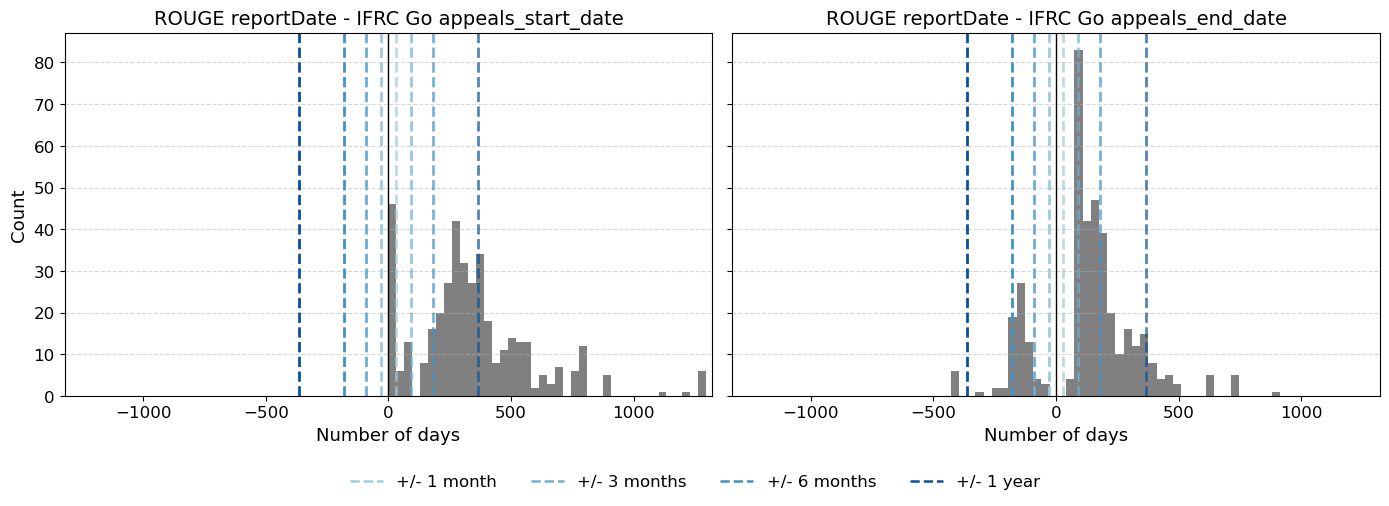

In [139]:
# Histograms of report date differences vs appeals start/end dates
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

thresholds = [30, 90, 30 * 6, 365]
threshold_labels = {30: "1 month", 90: "3 months", 180: "6 months", 365: "1 year"}
line_colors = ["#9ecae1", "#6baed6", "#4292c6", "#08519c"]

# Font sizes
title_fs = 14
label_fs = 13
tick_fs = 12
legend_fs = 12

hist_specs = [
    ("date_diff_start", "ROUGE reportDate - IFRC Go appeals_start_date"),
    ("date_diff_end", "ROUGE reportDate - IFRC Go appeals_end_date"),
]

# Use the same symmetric x-range for both plots
all_vals = pd.concat([df_result["date_diff_start"], df_result["date_diff_end"]], ignore_index=True).dropna()
if len(all_vals) > 0:
    max_abs = np.nanmax(np.abs(all_vals.values))
    x_lim = max(365, int(np.ceil(max_abs / 30.0) * 30))
else:
    x_lim = 365

for ax, (col, title) in zip(axes, hist_specs):
    vals = df_result[col].dropna()
    ax.hist(vals, bins=40, color="grey")

    # Add symmetric reference lines and labels directly above each line
    for d, c in zip(thresholds, line_colors):
        ax.axvline(d, color=c, linewidth=2, alpha=0.7, linestyle="--")
        ax.axvline(-d, color=c, linewidth=2, linestyle="--")

    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel("Number of days", fontsize=label_fs)
    ax.set_xlim(-x_lim, x_lim)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="both", labelsize=tick_fs)

axes[0].set_ylabel("Count", fontsize=label_fs)

# One shared legend for both subplots
legend_handles = [
    Line2D([0], [0], color=c, linestyle="--", linewidth=1.8, label=f"+/- {threshold_labels[d]}")
    for d, c in zip(thresholds, line_colors)
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=legend_fs,
 )

plt.tight_layout(rect=[0, 0.07, 1, 1])
#Save figure
fig.savefig(path_save_fig / f"comparaison_ifrc_go_report_dates.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"comparaison_ifrc_go_report_dates.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
plt.show()